# I. Enumerative Comb - output


这个课程 ipynb 和 slides-html 直接转换，非常好 EAUMP-ICTP , Arusha, Tanzania, July 24, 2023

SageMath Days:  Virtual community - Volunteer developers from around the world


<img src="https://raw.githubusercontent.com/tomctang/NB_img/main/sageday.png" alt="Map of Math" width="1000"> 

Sage for combinatorics

- Huge community!
- Not many other options for combinatorics: all developers contribute to SageMath
- Very well developed: Sage knows way more math than any combinatorialist does!

## Example of a combinatorial question
We can ask SageMath some simple questions, and it gives us the answer!

> How many subsets of $\{1,2,...,6\}$ have no two consecutive numbers?

## Example of a combinatorial question

> How many subsets of $\{1,2,...,6\}$ have no two consecutive numbers?

In [1]:
# Very naive algorithm
n = 6
S = Set(range(1, n+1))  # range(a, b) gives all the integers between a and b-1, including the boundary
number_not_consecutive = 0
for E in S.subsets():
    has_consecutive = False
    for e in E:
        if e + 1 in E:
            has_consecutive = True
            break  # to make the execution of the code shorter (will not ask for all e in E)
    if not has_consecutive:
        number_not_consecutive += 1  # Add 1 to number_not_consecutive
number_not_consecutive

21

## Example of a combinatorial question
We can generalize this question:

> How many subsets of $\{1,2,...,n\}$ have no two consecutive numbers?

In [2]:
# Very naive algorithm
sequence_no_consecutive = []
for n in range(10):
    S = Set(range(1, n+1))  # range(a, b) gives all the integers between a and b-1, including the boundary
    number_not_consecutive = 0
    for E in S.subsets():
        has_consecutive = False
        for e in E:
            if e + 1 in E:
                has_consecutive = True
                break  # to make the execution of the code shorter (will not ask for all e in E)
        if not has_consecutive:
            number_not_consecutive += 1  # Add 1 to number_not_consecutive
    sequence_no_consecutive.append(number_not_consecutive)
print(sequence_no_consecutive)

[1, 2, 3, 5, 8, 13, 21, 34, 55, 89]


## Example of a combinatorial question

What is this sequence?

In [3]:
# What is this sequence?
oeis(sequence_no_consecutive)

0: A000045: Fibonacci numbers: F(n) = F(n-1) + F(n-2) with F(0) = 0 and F(1) = 1.
1: A212804: Expansion of (1 - x)/(1 - x - x^2).
2: A324969: Number of unlabeled rooted identity trees with n vertices whose non-leaf terminal subtrees are all different.

In [4]:
# Is it really counted by the Fibonacci numbers?!
oeis.browse()

## Exploring SageMath's code

We can look up the documentation, and explore SageMath's code, right from the interface!

**Example** (for which you don't even need to know the math!)

> How many (integer) partitions of 13 have only parts at most 3?

In [5]:
Partitions?

Init signature: Partitions(is_infinite=False)
Docstring:     
   "Partitions(n, **kwargs)" returns the combinatorial class of
   integer partitions of n subject to the constraints given by the
   keywords.

   Valid keywords are: "starting", "ending", "min_part", "max_part",
   "max_length", "min_length", "length", "max_slope", "min_slope",
   "inner", "outer", "parts_in", "regular", and "restricted". They
   have the following meanings:

   * "starting=p" specifies that the partitions should all be less
     than or equal to p in lex order. This argument cannot be combined
     with any other (see
     https://github.com/sagemath/sage/issues/15467).

   * "ending=p" specifies that the partitions should all be greater
     than or equal to p in lex order. This argument cannot be combined
     with any other (see
     https://github.com/sagemath/sage/issues/15467).

   * "length=k" specifies that the partitions have exactly k parts.

   * "min_length=k" specifies that the partitions hav

In [6]:
len(Partitions(13, max_part=3))

21

## Exploring SageMath's code

Notice that we did not even need to know what a partition or a part is to solve this problem. But it is always good to know what you are doing (as a piece of advice...)

An *integer partition* (often just called a *partition*) of the number $n$ is a decreasing list of positive integers whose sum is $n$.

For example, $(2,1,1)$ is a partition of $4$.

## Exploring SageMath's code

How are partitions counted, anyway? We can read the source code by using `??`.

In [7]:
number_of_partitions??

Signature: number_of_partitions(n, algorithm='default')
Docstring:
   Return the number of partitions of n with, optionally, at most k
   parts.

   The options of "number_of_partitions()" are being deprecated
   https://github.com/sagemath/sage/issues/13072 in favour of
   "Partitions_n.cardinality()" so that "number_of_partitions()" can
   become a stripped down version of the fastest algorithm available
   (currently this is using FLINT).

   INPUT:

   * "n" -- integer

   * "algorithm" -- (default: "'default'")
        [Will be deprecated except in Partition().cardinality() ]

        * "'default'" -- if "k" is not "None", then use Gap (very
          slow);
             if  "k" is "None", use FLINT

        * "'flint'" -- use FLINT

   EXAMPLES:

      sage: v = Partitions(5).list(); v
      [[5], [4, 1], [3, 2], [3, 1, 1], [2, 2, 1], [2, 1, 1, 1], [1, 1, 1, 1, 1]]
      sage: len(v)
      7

   The input must be a nonnegative integer or a "ValueError" is
   raised.

      sage: 

The code refers to the algorithm 'FLINT', which stands for *Fast Library for Number Theory*. This means that it uses external code (that is included in Sage anyway), but this code might be written in another programming language.

We can verify that this is a fast algorithm, by asking Sage how long it takes to count partitions of 1000.

In [8]:
%time number_of_partitions(1000)

CPU times: user 1.91 ms, sys: 161 μs, total: 2.07 ms
Wall time: 8.83 ms


24061467864032622473692149727991

The algorithm is very fast to count all 24061467864032622473692149727991 partitions of 1,000.

Let us compare it with the method that enumerates all partitions, then counts them.

In [9]:
%time len(Partitions(1000))

OverflowError: cannot fit 'int' into an index-sized integer

There are too many partitions of 1,000 to store them before counting them.

## Combinatorial explosion


The size of many combinatorial sets grows *very* rapidly.
This is called the *combinatorial explosion*. It means that there exists a threshold where obtaining data is impossible. It can be because:
 - It takes too long.
 - It takes more memory (storage) than what our computer has.

In [10]:
print(f"There are {number_of_partitions(10)} partitions of 10, and {number_of_partitions(100)} partitions of 100.")
print(f"There are {factorial(4)} permutations of 4, and {factorial(10)} permutations of 10.")

There are 42 partitions of 10, and 190569292 partitions of 100.
There are 24 permutations of 4, and 3628800 permutations of 10.


Algorithms that are already in SageMath are often, not always, optimized to use just what is needed of memory and time.

If you want to do "large" computations, you have to be mindful of the limitations of your machine.

## Before you go...

Asking for help with SageMath:
-  Enter the name of the function, and add a question mark. This displays the **documentation**. Example: `number of partitions?`
-  Enter the name of the function, and add two question marks. This displays the **source code**. Example: `number of partitions??`
- Ask SageMath: [https://ask.sagemath.org/](https://ask.sagemath.org/) is a forum where people ask questions about Sage. Your question might have been asked before! You can also ask questions, but then you have to wait for the answer.
- There are a lot of information in the SageMath tutorials [https://doc.sagemath.org/html/en/tutorial/](https://doc.sagemath.org/html/en/tutorial/), but sometimes too much, and it can be hard to find what you are looking for.
- And as with many things, sometimes an internet search goes a long way. Make sure to enter SageMath, as there is a popular software also called Sage that is used for accounting.

# II. Combinatorial structures and statistics 

## Combinatorial structures

In Per's lecture, you learned about many combinatorial structures:
- Permutations
- Set Partitions
- Subsets
- Integer compositions
- Integer partitions

In Hans's lecture yesterday, you learned about some lattice paths.

SageMath already knows about all these!

## Generating objects from a combinatorial structure

In Sage, to generate instances of a combinatorial stucture (that Sage knows of), one simply uses the word with a capital letter.

In [11]:
p = Permutation([2,1,4,5,3]); p

[2, 1, 4, 5, 3]

In [12]:
p.to_cycles()

[(1, 2), (3, 4, 5)]

And to generate all instances of the combinatorial structure, one simply marks the plural.

In [13]:
P = Permutations(5); P

Standard permutations of 5

For example, one can ask how many permutations of 5 there are.

One can either generate all permutations and then count them (using `len(P)`), or one could ask SageMath to count them. For every structure, this is achieved through asking for the cardinality of a set.

In [14]:
print(len(P))
print(P.cardinality())

120
120


Of course, if we know that the number of permutations of $n$ is $n!$, one can simply ask how large is $n!$.

In [15]:
factorial(5)

120

In general, we could learn how the cardinality is computed.

**Takeaway**: SageMath is also a repository for knowledge, since it lists the desired theorems.

`P.cardinality??` shows
```python
Source:   
    def cardinality(self):
        """
        Return the number of permutations of size `n`, which is `n!`.

        EXAMPLES::

            sage: Permutations(0).cardinality()
            1
            sage: Permutations(3).cardinality()
            6
            sage: Permutations(4).cardinality()
            24
        """
        return factorial(self.n)

```
meaning that to compute the number of permutations of $n$, Sage only computes $n!$, and does not generate all permutations. 

`cardinality`:
- is much much faster: the computer needs not to write all permutations, just to multiply numbers
- is much much better on memory: the computer only remembers a number, and does not need space to write down all permutations
- allows to count permutations of a (not so) large number, while listing them is not doable

One must be mindful of memory and time, and that it induces limitations. Even though `cardinality` is fast, listing all permutations is not always possible.

In [16]:
Permutations(30).cardinality()

265252859812191058636308480000000

In [17]:
len(Permutations(30))

OverflowError: cannot fit 'int' into an index-sized integer

30 is too large to list all 30! permutations  🤷‍♀️

## Other combinatorial structures

- Set Partitions -> `SetPartitions`  (takes either a set as a parameter, or `n` for the set partitions of $\{1,2,\ldots, n\}$.)
- Subsets -> `Subsets` (takes either a set as a parameter, or `n` for the set partitions of $\{1,2,\ldots, n\}$.)
- Integer compositions -> `Compositions` (takes a positive integer as a parameter) 
- Integer partitions -> `Partitions` (takes a positive integer as a parameter) 
- Lattice paths: It depends on what type. For example for Dyck Paths, one can use `DyckWords`.

## Structures with constraints

Very often, we don't need to generate or count all instances of a structure, but only a subset with a specific constraint. Often, we can specifiy these 


**Example** (from last lecture)

> How many (integer) partitions of 13 have their largest part at most 3?

All instances -> All partitions of 13

What we are interested in -> Partitions of 13 with all parts at most 3

There are two options:
- Ask SageMath to generate only the partitions that have only parts at most 3 (through an *argument* in the generator, passed as a parameter).
- Ask SageMath to generate all partitions of 13, then sort through those whose maximal part is at most 3.

In [ ]:
# Do the example in class:
# Ask SageMath to generate only the partitions that have only parts at most 3
# through an *argument* in the generator, passed as a parameter.


In [18]:
# Do the example in class:
# Ask SageMath to generate only the partitions that have only parts at most 3
# through an *argument* in the generator, passed as a parameter.
list(Partitions(13, max_part=3))

[[3, 3, 3, 3, 1],
 [3, 3, 3, 2, 2],
 [3, 3, 3, 2, 1, 1],
 [3, 3, 3, 1, 1, 1, 1],
 [3, 3, 2, 2, 2, 1],
 [3, 3, 2, 2, 1, 1, 1],
 [3, 3, 2, 1, 1, 1, 1, 1],
 [3, 3, 1, 1, 1, 1, 1, 1, 1],
 [3, 2, 2, 2, 2, 2],
 [3, 2, 2, 2, 2, 1, 1],
 [3, 2, 2, 2, 1, 1, 1, 1],
 [3, 2, 2, 1, 1, 1, 1, 1, 1],
 [3, 2, 1, 1, 1, 1, 1, 1, 1, 1],
 [3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 [2, 2, 2, 2, 2, 2, 1],
 [2, 2, 2, 2, 2, 1, 1, 1],
 [2, 2, 2, 2, 1, 1, 1, 1, 1],
 [2, 2, 2, 1, 1, 1, 1, 1, 1, 1],
 [2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 [2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]

In [19]:
# Do the example in class:
# Ask SageMath to generate only the partitions that have only parts at most 3
# through an *argument* in the generator, passed as a parameter. Count the number of such partitions.
len(Partitions(13, max_part=3))

21

In [20]:
# Do the example in class:
# Ask SageMath to generate all partitions of 13, then sort through those whose maximal part is at most 3.


In [21]:
# Do the example in class:
# Ask SageMath to generate all partitions of 13, then sort through those whose maximal part is at most 3.
def list_partitions_with_max_part(n, max_part):
    result = []
    for p in Partitions(n):
        if p[0] <= max_part:  # p[0]is the largest part, since partitions are decreasing sequences
            result.append(p)
    return result

list_partitions_with_max_part(13, 3)

[[3, 3, 3, 3, 1],
 [3, 3, 3, 2, 2],
 [3, 3, 3, 2, 1, 1],
 [3, 3, 3, 1, 1, 1, 1],
 [3, 3, 2, 2, 2, 1],
 [3, 3, 2, 2, 1, 1, 1],
 [3, 3, 2, 1, 1, 1, 1, 1],
 [3, 3, 1, 1, 1, 1, 1, 1, 1],
 [3, 2, 2, 2, 2, 2],
 [3, 2, 2, 2, 2, 1, 1],
 [3, 2, 2, 2, 1, 1, 1, 1],
 [3, 2, 2, 1, 1, 1, 1, 1, 1],
 [3, 2, 1, 1, 1, 1, 1, 1, 1, 1],
 [3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 [2, 2, 2, 2, 2, 2, 1],
 [2, 2, 2, 2, 2, 1, 1, 1],
 [2, 2, 2, 2, 1, 1, 1, 1, 1],
 [2, 2, 2, 1, 1, 1, 1, 1, 1, 1],
 [2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 [2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]

In [22]:
# Using %time to see how fast this is
%time list_partitions_with_max_part(13, 3)

CPU times: user 852 μs, sys: 0 ns, total: 852 μs
Wall time: 917 μs


[[3, 3, 3, 3, 1],
 [3, 3, 3, 2, 2],
 [3, 3, 3, 2, 1, 1],
 [3, 3, 3, 1, 1, 1, 1],
 [3, 3, 2, 2, 2, 1],
 [3, 3, 2, 2, 1, 1, 1],
 [3, 3, 2, 1, 1, 1, 1, 1],
 [3, 3, 1, 1, 1, 1, 1, 1, 1],
 [3, 2, 2, 2, 2, 2],
 [3, 2, 2, 2, 2, 1, 1],
 [3, 2, 2, 2, 1, 1, 1, 1],
 [3, 2, 2, 1, 1, 1, 1, 1, 1],
 [3, 2, 1, 1, 1, 1, 1, 1, 1, 1],
 [3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 [2, 2, 2, 2, 2, 2, 1],
 [2, 2, 2, 2, 2, 1, 1, 1],
 [2, 2, 2, 2, 1, 1, 1, 1, 1],
 [2, 2, 2, 1, 1, 1, 1, 1, 1, 1],
 [2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 [2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]

In [23]:
# Using %timeit to see how fast this is. It does the computation multiple times.
# Notice that it does not print the output.
%timeit list(Partitions(13, max_part=3))

3.87 ms ± 317 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Of course, we should get the same answer regardless of how we generated the partitions.

In [24]:
Set(list_partitions_with_max_part(13, 3)) == Set(Partitions(13, max_part=3))

True

Phew! Sage and us got the same thing using two different methods.

**Question**: What are all constraints that one can easily give to SageMath for partitions?

In [25]:
# Figuring it out with the notebook

In [26]:
# To do that, we check in the documentation. We see that there is a lot.
Partitions?

Init signature: Partitions(is_infinite=False)
Docstring:     
   "Partitions(n, **kwargs)" returns the combinatorial class of
   integer partitions of n subject to the constraints given by the
   keywords.

   Valid keywords are: "starting", "ending", "min_part", "max_part",
   "max_length", "min_length", "length", "max_slope", "min_slope",
   "inner", "outer", "parts_in", "regular", and "restricted". They
   have the following meanings:

   * "starting=p" specifies that the partitions should all be less
     than or equal to p in lex order. This argument cannot be combined
     with any other (see
     https://github.com/sagemath/sage/issues/15467).

   * "ending=p" specifies that the partitions should all be greater
     than or equal to p in lex order. This argument cannot be combined
     with any other (see
     https://github.com/sagemath/sage/issues/15467).

   * "length=k" specifies that the partitions have exactly k parts.

   * "min_length=k" specifies that the partitions hav

## Numbers that SageMath know

SageMath knows many combinatorial sequences

- Factorial, `factorial`
- Bell numbers, `bell_number`
- Catalan numbers, `catalan_number`
- Narayana numbers, `narayana_number`
- Eulerian numbers, `eulerian_number` (and Eulerian polynomial, `eulerian_polynomial`)
- Fibonacci numbers, `fibonacci`
- Stirling numbers, of the first kind `stirling_number1`, and of the second kind
  `stirling_number2`.
- Polygonal numbers, `polygonal_number`

To find that list, you can look up the documentation, or I looked up the internet for `combinatorial sequences sagemath`.

If you don't know some of these numbers, ask the documentation:

`bell_number?` shows
```
Signature:      bell_number(n, algorithm='flint', **options) -> 'Integer'
Docstring:     
   Return the n-th Bell number.

   This is the number of ways to partition a set of n elements into
   pairwise disjoint nonempty subsets.

   INPUT:

   * "n" -- a positive integer

   * "algorithm" -- (Default: "'flint'") any one of the following:

     * "'dobinski'" -- Use Dobinski's formula implemented in Sage

     * "'flint'" -- Wrap FLINT's "arith_bell_number"

     * "'gap'" -- Wrap GAP's "Bell"

     * "'mpmath'" -- Wrap mpmath's "bell"
        

```

[...] The documentation is very long.

The list of sequences above all comes from the `combinat` part of SageMath. Some of them are not referenced in the main part of SageMath, so you'll have to import the combinat part.

In [27]:
narayana_number?

Object `narayana_number` not found.


In [28]:
from sage.combinat.combinat import *
narayana_number(5,2)

20

In [29]:
narayana_number?

Signature:      narayana_number(n: 'Integer', k: 'Integer') -> 'Integer'
Docstring:     
   Return the Narayana number of index "(n, k)".

   For every integer n >= 1, the sum of Narayana numbers \sum_k
   N_{n,k} is the Catalan number C_n.

   INPUT:

   * "n" -- integer

   * "k" -- integer between "0" and "n - 1"

   OUTPUT: integer

   EXAMPLES:

      sage: from sage.combinat.combinat import narayana_number
      sage: [narayana_number(3, i) for i in range(3)]
      [1, 3, 1]
      sage: sum(narayana_number(7,i) for i in range(7)) == catalan_number(7)
      True

   REFERENCES:

   * https://en.wikipedia.org/wiki/Narayana_number
Init docstring: Initialize self.  See help(type(self)) for accurate signature.
File:           ~/miniconda3/envs/sage-env/lib/python3.12/site-packages/sage/combinat/combinat.py
Type:           function

The Narayana numbers, according to Wikipedia, count the number of Dyck Paths with $2n$ steps and $k+1$ peaks. Can we draw these paths?

In [30]:
# Only a few appear on the slides, they are all in the notebook
for path in DyckWords(5):
    if len(path.peaks()) == 3:
        print(ascii_art(path), '\n')

      /\  
     /  \ 
/\/\/    \ 

   /\  /\ 
/\/  \/  \ 

      /\  
   /\/  \ 
/\/      \ 

    /\    
   /  \   
/\/    \/\ 

    /\    
   /  \/\ 
/\/      \ 

    /\/\  
   /    \ 
/\/      \ 

 /\    /\ 
/  \/\/  \ 

 /\  /\   
/  \/  \/\ 

 /\  /\/\ 
/  \/    \ 

 /\/\  /\ 
/    \/  \ 

      /\  
 /\/\/  \ 
/        \ 

    /\    
 /\/  \   
/      \/\ 

    /\    
 /\/  \/\ 
/        \ 

    /\/\  
 /\/    \ 
/        \ 

  /\      
 /  \     
/    \/\/\ 

  /\      
 /  \/\   
/      \/\ 

  /\      
 /  \/\/\ 
/        \ 

  /\/\    
 /    \   
/      \/\ 

  /\/\    
 /    \/\ 
/        \ 

  /\/\/\  
 /      \ 
/        \ 



## Different ways to draw objects

For example, one might be interested in drawing the paths in different ways, or to copy it in a LaTeX document.

For most objects, there are multiple ways to draw them. Typically:
- sometimes: just naming it does the work.
- `plot()`: displays it in a standard way
- `pp()`: pretty print in ascii art
- `ascii_art()`: a simple way to represent it visually
- `latex` or `show`: returns the LaTeX code for adding it to your document

In [31]:
path = DyckWords(5).random_element();
path

In [32]:
show(path)  # latex source

[1, 1, 1, 0, 0, 1, 0, 0, 1, 0]

In [33]:
# A more compact, yet visual representation (works for many structures)
ascii_art(path)

  /\      
 /  \/\   
/      \/\

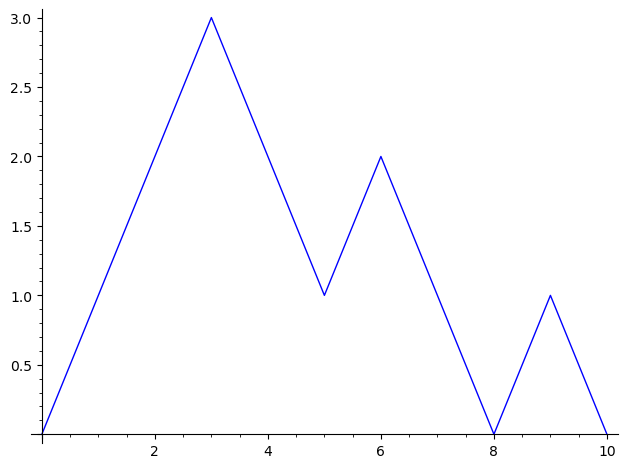

In [34]:
path.plot()  # draw it as a graphic

In [35]:
latex(path)  # also latex source

\vcenter{\hbox{$\begin{tikzpicture}[scale=1]
  \draw[dotted] (0, 0) grid (10, 3);
  \draw[rounded corners=1, color=black, line width=2] (0, 0) -- (1, 1) -- (2, 2) -- (3, 3) -- (4, 2) -- (5, 1) -- (6, 2) -- (7, 1) -- (8, 0) -- (9, 1) -- (10, 0);
\end{tikzpicture}$}}

In [36]:
path.pp()  # pp stands for "pretty print". Look how different it is!
# This is because a Dyck Path is also a lattice path that does not go below the diagonal.

         _
     ___| 
 ___| x  .
| x x  . .
| x  . . .
|  . . . .



# III. Generating functions

**Acknowledgements:** 
- Steven Melczer's [worksheet](https://melczer.ca/files/TextbookCode/Chapter2/Example2-4-VirahankaFibonacci.html) on the Fibonacci numbers

## A motivating example

Professor Balázs gave you this exercise:
> a. In how many ways can I pay 10 shillings if I am only allowed 1 and 2-shilling coins? How about 11 shillings? 20 shillings?

> b. In how many ways can I pay $n$ shillings, if I am only allowed 1 and 2-shilling coins? Can you find a general formula for the number of ways? Can you prove your formula?

I would like you to say how you would do it with combinatorial structures, as we saw them yesterday.


We want to partition the integer 10 in any way with only parts 1 and 2!

In [37]:
Partitions(10, max_part=2).cardinality()

6

We could also check how many that is for all the numbers between 10 and 20.

In [38]:
for n in range(10, 21):
    print(n, Partitions(n, max_part=2).cardinality())

10 6
11 6
12 7
13 7
14 8
15 8
16 9
17 9
18 10
19 10
20 11


It seems that the sequence is [1,2,2,3,3,4,4,,..].

If you did that exercise the way Professor Balász suggested you, you would get the generating function
$$f(x) = \frac{-x^2 + x + 1}{x^3 - x^2 - x + 1}.$$

Can we expand it as to get the answer for 10, 11 and 20 shillings all at once?

In [39]:
f(x) = (-x^2 + x + 1)/(x^3 - x^2 - x + 1)
f.series(x,21)

x |--> 1 + 2*x + 2*x^2 + 3*x^3 + 3*x^4 + 4*x^5 + 4*x^6 + 5*x^7 + 5*x^8 + 6*x^9 + 6*x^10 + 7*x^11 + 7*x^12 + 8*x^13 + 8*x^14 + 9*x^15 + 9*x^16 + 10*x^17 + 10*x^18 + 11*x^19 + 11*x^20 + Order(x^21)

**Generating functions** might seem like a complicated technique for this, in comparison with the partition approach. The power of generating function comes from the fact that one could get much more information about them. For example, we could simultaneously keep track of the number of coins needed for each way, and the amount. Then, the coefficients of the *bivariate generating functions* are the number of ways to pay a fixed amount using a fixed number of coins.

## Bivariate generating functions


### [Lecture at the board: bivariate generating functions]

### Motivating example: the chicken nuggets problem

McDonald's, a famous chain of fast food in America, used to sell chicken nuggets in packs of 6, 9 or 20. What is the largest number of nuggets that one cannot order?

In [40]:
S = (1/((1-x^6)*(1-x^9)*(1-x^20))).series(x,100); S

1 + 1*x^6 + 1*x^9 + 1*x^12 + 1*x^15 + 2*x^18 + 1*x^20 + 1*x^21 + 2*x^24 + 1*x^26 + 2*x^27 + 1*x^29 + 2*x^30 + 1*x^32 + 2*x^33 + 1*x^35 + 3*x^36 + 2*x^38 + 2*x^39 + 1*x^40 + 1*x^41 + 3*x^42 + 2*x^44 + 3*x^45 + 1*x^46 + 2*x^47 + 3*x^48 + 1*x^49 + 2*x^50 + 3*x^51 + 1*x^52 + 2*x^53 + 4*x^54 + 1*x^55 + 3*x^56 + 3*x^57 + 2*x^58 + 2*x^59 + 5*x^60 + 1*x^61 + 3*x^62 + 4*x^63 + 2*x^64 + 3*x^65 + 5*x^66 + 2*x^67 + 3*x^68 + 5*x^69 + 2*x^70 + 3*x^71 + 6*x^72 + 2*x^73 + 4*x^74 + 5*x^75 + 3*x^76 + 3*x^77 + 7*x^78 + 2*x^79 + 5*x^80 + 6*x^81 + 3*x^82 + 4*x^83 + 7*x^84 + 3*x^85 + 5*x^86 + 7*x^87 + 3*x^88 + 5*x^89 + 8*x^90 + 3*x^91 + 6*x^92 + 7*x^93 + 4*x^94 + 5*x^95 + 9*x^96 + 3*x^97 + 7*x^98 + 8*x^99 + Order(x^100)

I would like to know what powers do not appear in this expansion, without having to inspect it manually.

In [41]:
nonuggets = [t[1] for t in S.coefficients() if t[0]==0]
print("You cannot make packs of " + str(nonuggets))

You cannot make packs of [1, 2, 3, 4, 5, 7, 8, 10, 11, 13, 14, 16, 17, 19, 22, 23, 25, 28, 31, 34, 37, 43]


#### Two more combinatorial questions
> How many ways are there to make 60 chicken nuggets?

> How many of those ways use $7$ packs?

In [42]:
# How many ways are there to make 60 chicken nuggets?
# In class

In [43]:
# How many ways are there to make 60 chicken nuggets?
S.series(x, 61).coefficients()[60]

[5, 60]

There are 5 ways to get 60 chicken nuggets.

To get the number of ways that use 7 packs, I need a variable that keep tracks of the number of packs. Let $y$ be this variable.

Then, the generating function needs to be something like
$$\sum_{n\geq 0}\sum_{k\geq 0}\sum_{P\text{ partition of $n$ nuggets into $k$ packs of 6, 9 or 20}} y^k x^n.$$

This is the same as 
$$ \frac{1}{(1-yx^6) (1-yx^9)(1-yx^{20})}.$$

In [44]:
# In class

In [45]:
# In class
var('y')
Spacks = (1/((1-y*x^6)*(1-y*x^9)*(1-y*x^20)))

In [46]:
Spacks.series(x, 61)

1 + (y)*x^6 + (y)*x^9 + (y^2)*x^12 + (y^2)*x^15 + (y^3 + y^2)*x^18 + (y)*x^20 + (y^3)*x^21 + (y^4 + y^3)*x^24 + (y^2)*x^26 + (y^4 + y^3)*x^27 + (y^2)*x^29 + (y^5 + y^4)*x^30 + (y^3)*x^32 + (y^5 + y^4)*x^33 + (y^3)*x^35 + (y^6 + y^5 + y^4)*x^36 + ((y^3 + y^2)*y)*x^38 + (y^6 + y^5)*x^39 + (y^2)*x^40 + (y^4)*x^41 + (y^7 + y^6 + y^5)*x^42 + ((y^4 + y^3)*y)*x^44 + (y^7 + y^6 + y^5)*x^45 + (y^3)*x^46 + ((y^4 + y^3)*y)*x^47 + (y^8 + y^7 + y^6)*x^48 + (y^3)*x^49 + ((y^5 + y^4)*y)*x^50 + (y^8 + y^7 + y^6)*x^51 + (y^4)*x^52 + ((y^5 + y^4)*y)*x^53 + (y^9 + y^8 + y^7 + y^6)*x^54 + (y^4)*x^55 + ((y^6 + y^5 + y^4)*y)*x^56 + (y^9 + y^8 + y^7)*x^57 + ((y^3 + y^2)*y^2)*x^58 + ((y^6 + y^5)*y)*x^59 + (y^10 + y^9 + y^8 + y^7 + y^3)*x^60 + Order(x^61)

In [47]:
Spacks.series(x, 61).coefficients()[60]

[y^10 + y^9 + y^8 + y^7 + y^3, 60]

So there is a single way to make 7 packs of nuggets, for a total of 60.

We can also add variables that keep track of all the types of packs (either *six* ($s$), *nine* ($n$) or *twenty* ($t$)).

In [48]:
# In class


In [49]:
# In class
var('s,n,t')
Sdifferentpacks = (1/((1-s*x^6)*(1-n*x^9)*(1-t*x^20)))
Sdifferentpacks.series(x, 61)

1 + (s)*x^6 + (n)*x^9 + (s^2)*x^12 + (n*s)*x^15 + (s^3 + n^2)*x^18 + (t)*x^20 + (n*s^2)*x^21 + (s^4 + n^2*s)*x^24 + (s*t)*x^26 + (n*s^3 + n^3)*x^27 + (n*t)*x^29 + (s^5 + n^2*s^2)*x^30 + (s^2*t)*x^32 + (n*s^4 + n^3*s)*x^33 + (n*s*t)*x^35 + (s^6 + n^2*s^3 + n^4)*x^36 + ((s^3 + n^2)*t)*x^38 + (n*s^5 + n^3*s^2)*x^39 + (t^2)*x^40 + (n*s^2*t)*x^41 + (s^7 + n^2*s^4 + n^4*s)*x^42 + ((s^4 + n^2*s)*t)*x^44 + (n*s^6 + n^3*s^3 + n^5)*x^45 + (s*t^2)*x^46 + ((n*s^3 + n^3)*t)*x^47 + (s^8 + n^2*s^5 + n^4*s^2)*x^48 + (n*t^2)*x^49 + ((s^5 + n^2*s^2)*t)*x^50 + (n*s^7 + n^3*s^4 + n^5*s)*x^51 + (s^2*t^2)*x^52 + ((n*s^4 + n^3*s)*t)*x^53 + (s^9 + n^2*s^6 + n^4*s^3 + n^6)*x^54 + (n*s*t^2)*x^55 + ((s^6 + n^2*s^3 + n^4)*t)*x^56 + (n*s^8 + n^3*s^5 + n^5*s^2)*x^57 + ((s^3 + n^2)*t^2)*x^58 + ((n*s^5 + n^3*s^2)*t)*x^59 + (s^10 + n^2*s^7 + n^4*s^4 + n^6*s + t^3)*x^60 + Order(x^61)

In [50]:
var('s,n,t')
(1/(1-s*x^6 - n*x^9 - t*x^20)).series(x,100).coefficients()[60][0].expand()

s^10 + 36*n^2*s^7 + 70*n^4*s^4 + 7*n^6*s + t^3

### Multivariate generating functions: Takeaway

Actually, there is no limit on the number of variables one can define, but it might be hard to keep track of all the information we are interested in.

## Getting the generating function

I think you have seen two types of recursions to play with generating functions: a simpler one is linear recursion, and another one uses the symbolic method.

## Catalan generating function using the symbolic method


In Hans's lecture on Monday, he did a long computation to get the Catalan numbers from the symbolic method.

Let $F$ be the generating function for Dyck paths, and let $x$ track the number of pairs of steps (one up, one down). Using the first return, we saw that the generating function $$C = \sum_{P \text{ Dyck Paths}} x^{\# \text{up-steps}(P)}$$ satisifes the equation $C = 1 + xC^2$. 

> Pass this generating function to Sage.

In [51]:
# In class


In [52]:
C, x = var('C,x')
sys = [ C == x*C^2+1]

Now, let's solve this generating function. As we saw in Hans's lecture, there are two answers, but only one has nice coefficients.

In [53]:
# In class
solve(sys, C)

[C == -1/2*(sqrt(-4*x + 1) - 1)/x, C == 1/2*(sqrt(-4*x + 1) + 1)/x]

In [54]:
sol = _

In [55]:
sol = solve(sys, C); sol

[C == -1/2*(sqrt(-4*x + 1) - 1)/x, C == 1/2*(sqrt(-4*x + 1) + 1)/x]

There are two solutions, only one of which is right. Expand them to figure out how to do that.

In [56]:
# In class
sol[0].right_hand_side().series(x)

1 + 1*x + 2*x^2 + 5*x^3 + 14*x^4 + 42*x^5 + 132*x^6 + 429*x^7 + 1430*x^8 + 4862*x^9 + 16796*x^10 + 58786*x^11 + 208012*x^12 + 742900*x^13 + 2674440*x^14 + 9694845*x^15 + 35357670*x^16 + 129644790*x^17 + 477638700*x^18 + 1767263190*x^19 + Order(x^20)

In [57]:
sol[1].right_hand_side().series(x)

1*x^(-1) + (-1) + (-1)*x + (-2)*x^2 + (-5)*x^3 + (-14)*x^4 + (-42)*x^5 + (-132)*x^6 + (-429)*x^7 + (-1430)*x^8 + (-4862)*x^9 + (-16796)*x^10 + (-58786)*x^11 + (-208012)*x^12 + (-742900)*x^13 + (-2674440)*x^14 + (-9694845)*x^15 + (-35357670)*x^16 + (-129644790)*x^17 + (-477638700)*x^18 + (-1767263190)*x^19 + Order(x^20)

In [58]:
C1(x) = sol[0].right_hand_side(); C2(x) = sol[1].right_hand_side()

In [59]:
# In class

In [60]:
# In class

In [61]:
C1.series(x)

x |--> 1 + 1*x + 2*x^2 + 5*x^3 + 14*x^4 + 42*x^5 + 132*x^6 + 429*x^7 + 1430*x^8 + 4862*x^9 + 16796*x^10 + 58786*x^11 + 208012*x^12 + 742900*x^13 + 2674440*x^14 + 9694845*x^15 + 35357670*x^16 + 129644790*x^17 + 477638700*x^18 + 1767263190*x^19 + Order(x^20)

In [62]:
C2.series(x)

x |--> 1*x^(-1) + (-1) + (-1)*x + (-2)*x^2 + (-5)*x^3 + (-14)*x^4 + (-42)*x^5 + (-132)*x^6 + (-429)*x^7 + (-1430)*x^8 + (-4862)*x^9 + (-16796)*x^10 + (-58786)*x^11 + (-208012)*x^12 + (-742900)*x^13 + (-2674440)*x^14 + (-9694845)*x^15 + (-35357670)*x^16 + (-129644790)*x^17 + (-477638700)*x^18 + (-1767263190)*x^19 + Order(x^20)

The latter has a lot of negative numbers, so we should avoid it. Then, the Dyck Paths would be counted by the generating function 'C1' here,

In [63]:
C1 = sol[0].rhs()
C1.series(x, 10)

1 + 1*x + 2*x^2 + 5*x^3 + 14*x^4 + 42*x^5 + 132*x^6 + 429*x^7 + 1430*x^8 + 4862*x^9 + Order(x^10)

In [64]:
oeis([1, 1, 2, 5, 14, 42, 132, 429, 1430])  # Requires internet.

0: A000108: Catalan numbers: C(n) = binomial(2n,n)/(n+1) = (2n)!/(n!(n+1)!).
1: A120588: G.f. is 1 + x*c(x), where c(x) is the g.f. of the Catalan numbers (A000108).
2: A211216: Expansion of (1-8*x+21*x^2-20*x^3+5*x^4)/(1-9*x+28*x^2-35*x^3+15*x^4-x^5).

We can inspect the OEIS entry A000108 to see that what we got is indeed the generating function for the Catalan numbers. 

In [65]:
oeis('A000108').formulas()[0:4]

0: a(n) = binomial(2*n, n)/(n+1) = (2*n)!/(n!*(n+1)!) = A000984(n)/(n+1).
1: Recurrence: a(n) = 2*(2*n-1)*a(n-1)/(n+1) with a(0) = 1.
2: Recurrence: a(n) = Sum_{k=0..n-1} a(k)a(n-1-k).
3: G.f.: A(x) = (1 - sqrt(1 - 4*x)) / (2*x), and satisfies A(x) = 1 + x*A(x)^2.

## Generating functions: What Sage can and cannot do.

What Sage easily does for us:
- Taking the recurrence
- Solving it, giving the generating function
- Expanding it; giving any (finite) number of terms

What Sage struggles with; it's something you can do, but it requires effort and knowledge:
- Giving a closed form for the coefficients
- Expanding infinite sums

Some other computer algebra systems do it better than SageMath. Some optional packages can be added to SageMath to do it, but it is still not that simple.

## Linear recurrence


The simpler case is a linear recurrence: something of the form $A_{n} = a\cdot a_{n-1}+b\cdot a_{n-2}+c\cdot a_{n-3}+\ldots$.

A linear recurrence is also called a C-finite sequence. Hence, we can explore the space of `CFiniteSequences`.

### Fibonacci numbers

Recall that the Fibonacci numbers are defined using $F_0 = 1$, $F_1 =1$ and $F_n = F_{n-1}+F_{n-2}$ for $n\geq 2$.

In [66]:
# Define the ring of C-finite sequences over the rationals; a C-finite sequence is a recurrence
C.<x> = CFiniteSequences(QQ)

# Give the recurrence to SageMath. This code can be modified for other recurrences.
fibo = C.from_recurrence([1,1],[1,1]) # Recurrence F_{n+2} = F_{n+1} + F_n with v_0 = v_1 = 1
fibo

C-finite sequence, generated by -1/(x^2 + x - 1)

We got a generating function for the sequence. Can we get other informations, like the coefficients or the partial fraction decomposition?

In [67]:
fibo.series(10).coefficients()

[1, 1, 2, 3, 5, 8, 13, 21, 34, 55]

In [68]:
fibo[1000]

70330367711422815821835254877183549770181269836358732742604905087154537118196933579742249494562611733487750449241765991088186363265450223647106012053374121273867339111198139373125598767690091902245245323403501

We can even get easily the partial fraction decomposition...

In [69]:
# In class


In [70]:
# In class
F = fibo.ogf()
F.partial_fraction_decomposition()

(0, [-1/(x^2 + x - 1)])

In [71]:
ogf_fibo = fibo.ogf()  # ogf stands for 'ordinary generating function'
ogf_fibo

-1/(x^2 + x - 1)

In [72]:
ogf_fibo.partial_fraction_decomposition?

Signature:      ogf_fibo.partial_fraction_decomposition(decompose_powers=True)
Docstring:     
   Decompose fraction field element into a whole part and a list of
   fraction field elements over prime power denominators.

   The sum will be equal to the original fraction.

   INPUT:

   * "decompose_powers" -- boolean (default: "True"); whether to
     decompose prime power denominators as opposed to having a single
     term for each irreducible factor of the denominator

   OUTPUT: partial fraction decomposition of "self" over the base ring

   AUTHORS:

   * Robert Bradshaw (2007-05-31)

   EXAMPLES:

      sage: S.<t> = QQ[]
      sage: q = 1/(t+1) + 2/(t+2) + 3/(t-3); q
      (6*t^2 + 4*t - 6)/(t^3 - 7*t - 6)
      sage: whole, parts = q.partial_fraction_decomposition(); parts
      [3/(t - 3), 1/(t + 1), 2/(t + 2)]
      sage: sum(parts) == q
      True
      sage: q = 1/(t^3+1) + 2/(t^2+2) + 3/(t-3)^5
      sage: whole, parts = q.partial_fraction_decomposition(); parts
      [1/

Here, however, the denominator cannot we factored over $\mathbb{Q}$, so it is already decomposed.

In [73]:
factor(x^2+x-1)

x^2 + x - 1

In [74]:
# In comparison...
factor(x^2-1)

(x - 1) * (x + 1)

**Decomposition over another field**

It is possible to decompose it over other fields than $\mathbb{Q}$, but we must let SageMath know that we want to do this.

In [75]:
R.<x> = PolynomialRing(RR)  # CC stands for complex, RR for real, QQ for rational, ZZ for integers, QQbar for algebraic, etc. 
factor(x^2+x-1)

(x - 0.618033988749895) * (x + 1.61803398874989)

There is even a way to 'guess' a generating function from a few coefficients. However, the sequence **must** be a linear recurrence.

In [76]:
C.guess([1,2,4,8,16,32])

C-finite sequence, generated by -1/2/(x - 1/2)

For this to work, we must feed the 'guess' function enough terms.

In [77]:
seq = C.from_recurrence([5,2,1],[7,9])
seq.series(10)

7 + 9*x + 23*x^2 + 76*x^3 + 167*x^4 + 434*x^5 + 1148*x^6 + 2851*x^7 + 7317*x^8 + 18759*x^9 + O(x^10)

In [78]:
# I secretly generated a sequence from a recurrence. Here are the first terms.
mystery = _.coefficients(); mystery

[7, 9, 23, 76, 167, 434, 1148, 2851, 7317, 18759]

In [79]:
C.guess([7, 9, 23, 76, 167, 434])

0

In [80]:
C.guess([7, 9, 23, 76, 167, 434, 1148, 2851, 7317])

C-finite sequence, generated by (-2/5*x - 7/5)/(x^3 + 2/5*x^2 + 1/5*x - 1/5)

Now that we have the sequence, we can ask for the recurrence. This is exactly what I inputed SageMath (in secret)!

In [81]:
_.recurrence_repr()

'homogeneous linear recurrence with constant coefficients of degree 3: a(n+3) = a(n+2) + 2*a(n+1) + 5*a(n), starting a(0...) = [7, 9, 23]'

## Takeaway

- SageMath knows a lot of tools to make our life with generating functions simpler.
- SageMath has a lot of things here and there for generating functions, but would benefit from a uniform framework and a greater ease of use!

**Open problem**: Make a uniform framework for generating functions in SageMath!

# IV. Graphs

## Graphs
A **graph** is given by a set of *vertices* and a set of *edges* connecting the vertices. Just that!

Graphs are very useful to represent connections between people, networks, etc. A lot of theory exists on them!

In [82]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [6, 3]  # to make the figures smaller, so they fit on slides

## Motivation

> Can you draw these pictures without ever crossing your path?

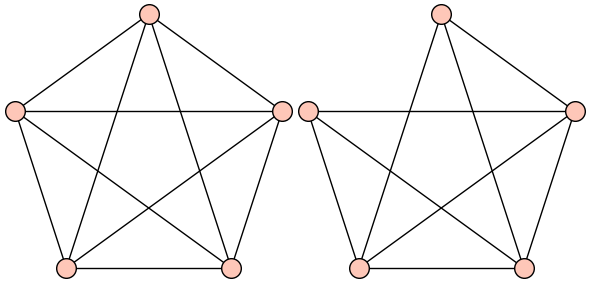

In [83]:
A = graphs.CompleteGraph(5)
B = A.copy(); B.delete_edge([0,1])
graphics_array([A.plot(vertex_labels=False), B.plot(vertex_labels=False)])

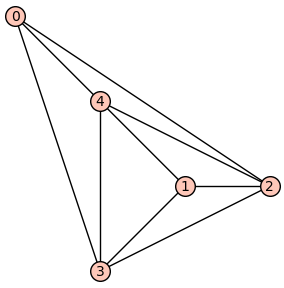

In [84]:
B.plot(layout='planar')

When we ask this question in graph theory, we mean 'Can we draw a picture *equivalent to this one*, in the sense that the same vertices are connected?'

> Can you draw this graph without ever lifting your pen? 

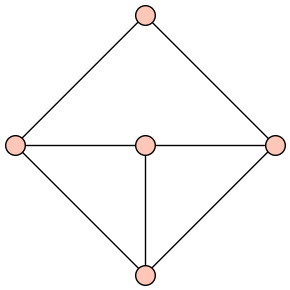

In [85]:
A = graphs.WheelGraph(5)
A.delete_edge([0,1])
A.plot(vertex_labels=False)

These problems look like children problems because the graphs are small, but we could ask the same question for much much larger graphs.

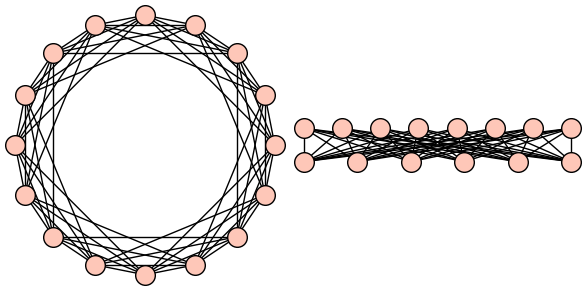

In [86]:
graphics_array([graphs.HararyGraph(8,16).plot(vertex_labels=False),graphs.CompleteBipartiteGraph(8,6).plot(vertex_labels=False)])

## Motivation
> How many colours do you need to draw a map of Africa so that no two adjacent countries have the same colour ?

We already know that we needed at least 4 colours, since Uganda, Rwanda, Tanzania and the DRC are all adjacent.
The *four color theorem* tells us that any map can be colored with only 4 colors so that no two countries are adjacent.
SageMath can confirm that.

In [87]:
# This number is called the chromatic number of a graph
G = graphs.AfricaMap()  # already in SageMath
G.chromatic_number()

4

More interestingly, SageMath can tell us how to use for what country.

In [88]:
c = G.coloring()

In [89]:
for i in range(4):
    s = ''
    for country in c[i]:
        s += str(country)
        s += ", "
    print(s)

Algeria, Chad, Burkina Faso, Republic of the Congo, South Sudan, Tanzania, Senegal, Liberia, Namibia, Zimbabwe, Equatorial Guinea, Eritrea, Somalia, Egypt, Swaziland, Lesotho, Cape Verde, Seychelles, Mauritius, São Tomé and Príncipe, Madagascar, Comoros, 
Libya, Mali, Benin, Cameroon, Democratic Republic of the Congo, Ethiopia, Mozambique, Ghana, Botswana, Guinea-Bissau, Sierra Leone, Morocco, Gambia, 
Niger, Central Africa, Angola, Gabon, Kenya, Rwanda, Malawi, Mauritania, Guinea, Tunisia, South Africa, Togo, Djibouti, 
Nigeria, Sudan, Uganda, Zambia, Burundi, Ivory Coast, 


Then we can export that list to some online tools that can plot for us the map. 

*Notice that `G.coloring()` does not always return the same coloring, so the list above might not match the picture below.*

<img src="images/Africa_4colors.png" width="500">

## Constructing graphs in SageMath

Recall that a graph is **a set of vertices and a set of edges** between these vertices.

This is the data that SageMath takes to construct graphs, even though they can be constructed in many ways.

> Find how to construct a graph in SageMath.

In [90]:
Graph?

Init signature:
Graph(
    data=None,
    pos=None,
    loops=None,
    format=None,
    weighted=None,
    data_structure='sparse',
    vertex_labels=True,
    name=None,
    multiedges=None,
    convert_empty_dict_labels_to_None=None,
    sparse=True,
    immutable=False,
    hash_labels=None,
)
Docstring:     
   Undirected graph.

   A graph is a set of vertices connected by edges. See the
   https://en.wikipedia.org/wiki/Graph_(mathematics) for more
   information. For a collection of pre-defined graphs, see the
   "graph_generators" module.

   A "Graph" object has many methods whose list can be obtained by
   typing "g.<tab>" (i.e. hit the "Tab" key) or by reading the
   documentation of "graph", "generic_graph", and "digraph".

   INPUT:

   By default, a "Graph" object is simple (i.e. no *loops* nor
   *multiple edges*) and unweighted. This can be easily tuned with the
   appropriate flags (see below).

   * "data" -- can be any of the following (see the "format"
     argument

The documentation says that a graph is created with some *data*, that can be any of the following.
   1. "Graph()" -- build a graph on 0 vertices.
   2. "Graph(5)" -- return an edgeless graph on the 5 vertices
      0,...,4.
   3. "Graph([list_of_vertices, list_of_edges])" -- returns a graph
      with given vertices/edges.
   4. "Graph(list_of_edges)" -- return a graph with a given list of
      edges (see documentation of "add_edges()").
   5. "Graph({1: [2, 3, 4], 3: [4]})" -- return a graph by
      associating to each vertex the list of its neighbors.
   6. "Graph({1: {2: 'a', 3:'b'} ,3:{2:'c'}})" -- return a graph by
      associating a list of neighbors to each vertex and providing
      its edge label.
   7. "Graph(a_symmetric_matrix)" -- return a graph with given
      (weighted) adjacency matrix (see documentation of
      "adjacency_matrix()").
   8. "Graph(a_nonsymmetric_matrix)" -- return a graph with given
      incidence matrix (see documentation of "incidence_matrix()").
[...]

SageMath also knows **a lot** of common graphs. These are accessed by typing `graphs.[tab]`

In [91]:
# In class

What is your favorite graph?

## Create the following graph, in class
<img src="images/bowtie.png" width="200">

In [92]:
# In class

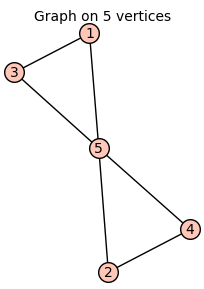

In [93]:
# In class
V = [1,2,3,4,5]
E = [[1,3], [1,5], [2,5], [2,4], [3,5], [4,5]]
Graph(E)

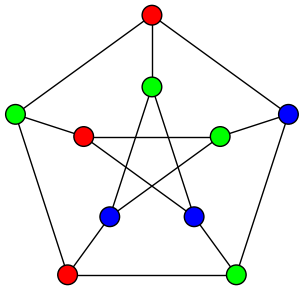

In [94]:
# A graph I like
G = graphs.PetersenGraph(); c = G.coloring(hex_colors=True); G.plot(vertex_colors=c, vertex_labels=False)

### Some homework problems that my students could use SageMath for.
> Prove or disprove: All hypercubes are bipartite.

> What is the number of non-loop edges in the De Bruijn digraph Dn (for n ≥ 2)? Prove your answer

> Are the following graphs planar? Prove your answer. (a) The complete bipartite graph $K_{4,2}$ (b) The hypercube $H_3$ (c) The Petersen graph

> Prove or disprove: All hypercubes are bipartite.

Won't give a proof, but might either give a counterexample, or convince one to prove it.

In [95]:
for n in range(1, 10):
    print(n, graphs.CubeGraph(n).is_bipartite())

1 True
2 True
3 True
4 True
5 True
6 True
7 True
8 True
9 True


**Theorem**: All hypergraphs are bipartite.

(The proof can be done easily, by writing the coordinates as tuples over 0 and 1 and taking their sum. All the neighbors of an odd-sum vertex have an even sum.)

> What is the number of non-loop edges in the De Bruijn digraph Dn (for n ≥ 2)? Prove your answer

Again, won't give a proof, but we could count it for all small values of $n$,

In [96]:
for n in range(1, 10):
    G = digraphs.DeBruijn(2, n)
    print(n, len(G.edges()) - len(G.loop_edges()))

1 2
2 6
3 14
4 30
5 62
6 126
7 254
8 510
9 1022


**Conjecture**: the number of non-loop edges in a DeBruijn graph for $n$ is $2^{n+1}-2$.

It is not hard to prove, but we would need to know what a DeBruijn graph is, and to understand it.

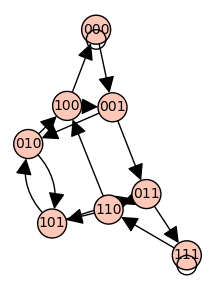

In [97]:
digraphs.DeBruijn(2,3).plot(vertex_size=800)

A *De Bruijn* graph has for vertices all the binary sequence of a given length, and there is an arrow connecting two sequences if taking the tail removing the first letter and replacing the last letter by anything, we can get the tip of the arrow.

It has $2^n$ vertices, $2^{n+1}$ edges, and only two of them are loops (`000...0 -> 000...0`and `111...1 -> 111...1`).

> Are the following graphs planar? Prove your answer. (a) The complete bipartite graph $K_{4,2}$ (b) The hypercube $H_3$ (c) The Petersen graph

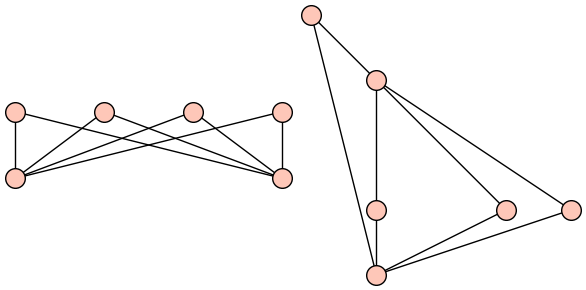

In [98]:
G = graphs.CompleteBipartiteGraph(4,2)
graphics_array([G.plot(vertex_labels=False), G.plot(layout='planar', vertex_labels=False)])

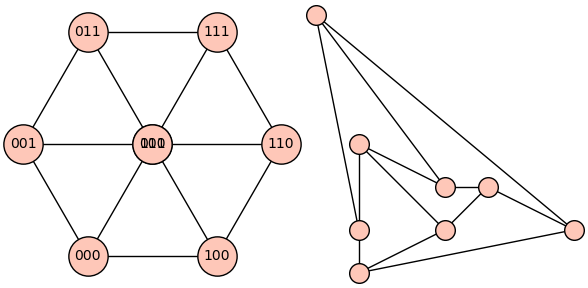

In [99]:
G = graphs.CubeGraph(3)
graphics_array([G.plot(vertex_labels=True, vertex_size=800), G.plot(layout='planar', vertex_labels=False)])

In [100]:
G = graphs.PetersenGraph()
G.is_planar()

False

The cube and the complete bipartite graph $K_{4,2}$ are planar, the Petersen graph is not.

### Takeaways
- SageMath would be a good help for my student's homeworks (at least for some problems)
- SageMath does not always give the most natural or clever visual representation. But, it has a lot of parameters to customize the presentation.
- Also, other tools in Python, for example, are much better for visualization. 

## A few classical problems  in graph theory
Given a graph, what is...
- ... the distance between two given vertices?
- ... the minimum number of edges that one needs to remove to disconnect the graph (this is the *edge-connectivity*)?
- ... the largest set of vertices that have no edge in between (the largest independent set)?
- ... the minimum number of colours needed to colour the vertices, so that two adjacent vertices have different colours; this is the *chromatic number*?
- ... a shortest path between two given vertices?
- ... the size of the largest clique: a *clique* is a complete subgraph?

SageMath knows all of them!

> In class. Generate a random graph with 15 vertices, in which each edge appears with probability 0.3
Then solve all the problems above.

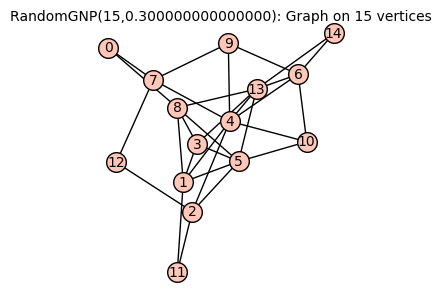

In [101]:
# In-class work
G = graphs.RandomGNP(15, 0.3); G  # parameters are # of vertices and probability of an edge to be in the graph

In [102]:
# In-class work

In [103]:
# In-class work

In [104]:
# In-class work

In [105]:
# In-class work

In [106]:
# In-class work

In [107]:
## Solutions are below

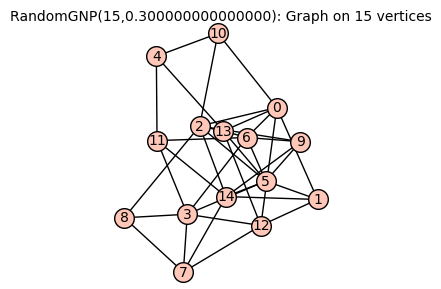

In [108]:
G = graphs.RandomGNP(15, 0.3); G

In [109]:
G.distance(2, 14)

1

In [110]:
G.edge_connectivity()

3

In [111]:
len(G.independent_set())

6

In [112]:
G.chromatic_number()

4

In [113]:
G.shortest_path(2, 14)

[2, 14]

In [114]:
G.clique_number()

4

## Display
For each of the problems above, we can illustrate this directly on the graph. We will explore the drawing options together, and solve each of the problems above.

Given a graph, what is...
- ... the distance between two given vertices?
- ... the minimum number of edges that one needs to remove to disconnect the graph (this is the *edge-connectivity*)?
- ... the largest set of vertices that have no edge in between (the largest independent set)?
- ... the minimum number of colours needed to colour the vertices, so that two adjacent vertices have different colours; this is the *chromatic number*?
- ... a shortest path between two given vertices?
- ... the size of the largest clique: a *clique* is a complete subgraph?

In [115]:
# In class

In [116]:
# In class

In [117]:
# In class

In [118]:
# In class

In [119]:
# In class

Some solutions are below.

In [120]:
edges_in_path = []
p = G.shortest_path(2,14)
for i in range(len(p[:-1])):
    edges_in_path.append([p[i], p[i+1]])
edges_in_path

[[2, 14]]

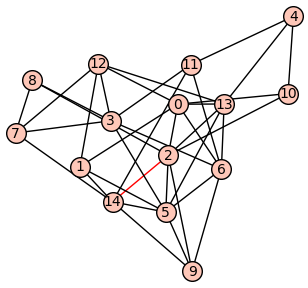

In [121]:
# Shortest path between 2 and 14
G.plot(edge_colors=dict([('red', edges_in_path)]))

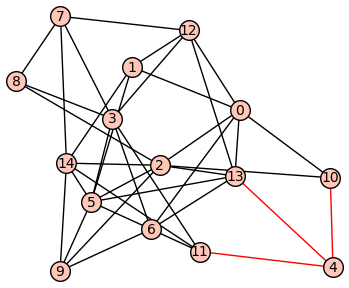

In [122]:
C = G.edge_connectivity(value_only=False)
G.plot(edge_colors=dict([('red', C[1])]))  # displays an edge-cut

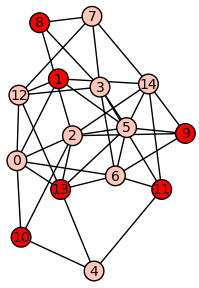

In [123]:
# Largest independent set
I = G.independent_set()
G.plot(vertex_colors=dict([('red', I)]))

Etc. [Solutions here will be added later]

## A quiz!

The *chromatic number* of a graph is the minimum number of colours needed to colour all vertices such that no two adjacent vertices (so vertices that share an edge) have the same colour.

> What is the chromatic number of the following graphs?

#### For 1 point:

In [124]:
G = graphs.CompleteGraph(6)

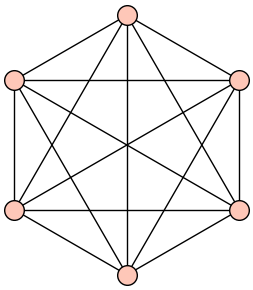

In [125]:
G.plot(vertex_labels=False)

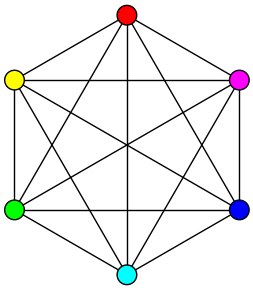

In [126]:
c = G.coloring(hex_colors=True); G.plot(vertex_colors=c, vertex_labels=False)

For complete graphs, so graphs for which all possible exist, the chromatic number is the number of vertices.

#### For 1 point:

In [127]:
G = graphs.CompleteBipartiteGraph(6,7)

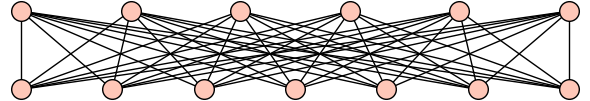

In [128]:
G.plot(vertex_labels=false)

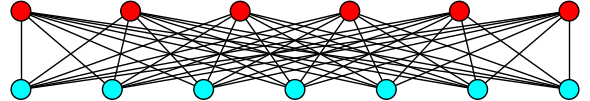

In [129]:
c = G.coloring(hex_colors=True); G.plot(vertex_colors=c, vertex_labels=False)

This is a bipartite graph (because there is no edge from the top set to the top set, or between two vertices of the bottom set). All vertices of the top can be coloured the same, just like all the vertices in the bottom.

#### For 1 point:

In [130]:
G = graphs.CycleGraph(7)

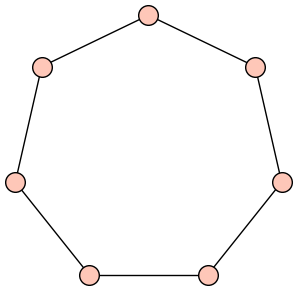

In [131]:
G.plot(vertex_labels=False)

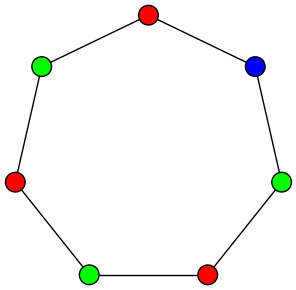

In [132]:
c = G.coloring(hex_colors=True); G.plot(vertex_colors=c, vertex_labels=False)

Cycles of odd length need to be colored with 3 different colors.

#### For 1 point:

In [133]:
G = graphs.CycleGraph(6)

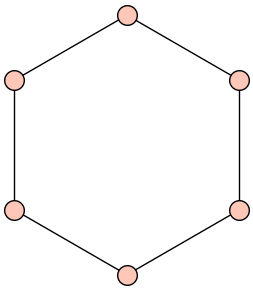

In [134]:
G.plot(vertex_labels=False)

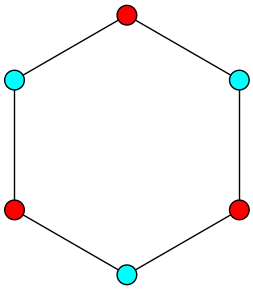

In [135]:
c = G.coloring(hex_colors=True); G.plot(vertex_colors=c, vertex_labels=False)

Cycles of even length are bipartite graphs, so they can be colored with two colors.

#### For 2 points:

In [136]:
G = graphs.GrotzschGraph()  # Equivalent to Mycielski's graph of order 4

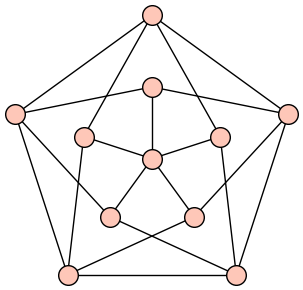

In [137]:
G.plot(vertex_labels=False)

#### For 1 point if you accept the hint:

Hint:  This is called the Mycielski graph of order 4.

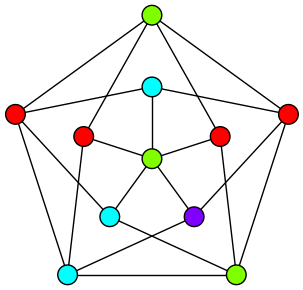

In [138]:
c = G.coloring(hex_colors=True); G.plot(vertex_colors=c, vertex_labels=False)

Mycielski's do not contain any triangle, but they have arbitrary large chromatic numbers.

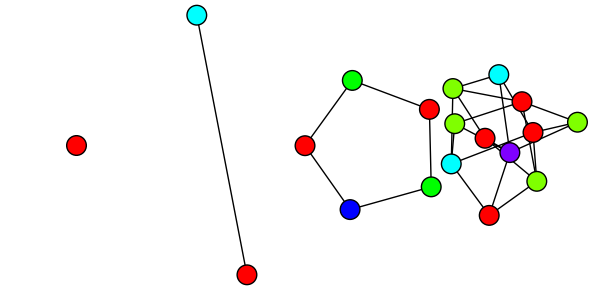

In [139]:
graphics_array([graphs.MycielskiGraph(i).plot(vertex_labels=False, vertex_colors=graphs.MycielskiGraph(i).coloring(hex_colors=True)) for i in range(1,5)])

#### For 2 points:

In [140]:
G = graphs.CubeGraph(4)

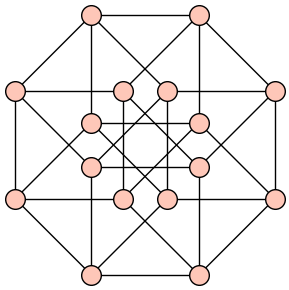

In [141]:
G.plot(vertex_labels=False)

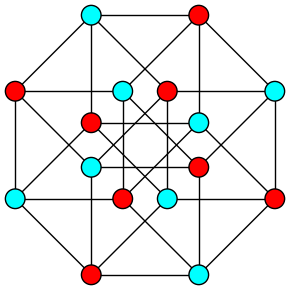

In [142]:
c = G.coloring(hex_colors=True); G.plot(vertex_colors=c, vertex_labels=False)

This is the hypercube of dimension 4, and hypercubes are bipartite.

### Planarity questions

Are the following graphs **planar**? A graph is *planar* if it can be drawn without edge crossings.

#### For 1 point:

In [143]:
G = graphs.CompleteGraph(4)

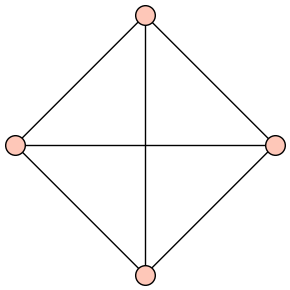

In [144]:
G.plot(vertex_labels=False)

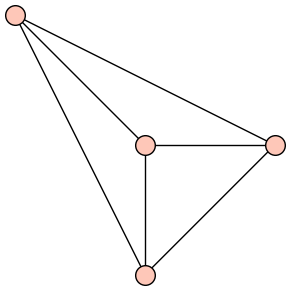

In [145]:
G.plot(vertex_labels=False, layout='planar')

The complete graph on four vertices is also the skeleton of the tetrahedron, and can be drawn in a planar way.

#### For 1 point:

In [146]:
G = graphs.CompleteGraph(5)

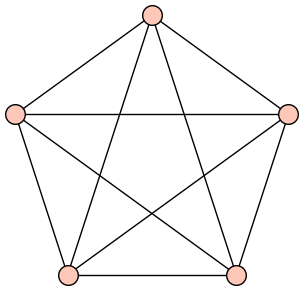

In [147]:
G.plot(vertex_labels=False)

The complete graph on five vertices is the smallest graph that is not planar.

#### For 1 point:

In [148]:
G = graphs.CubeGraph(3)

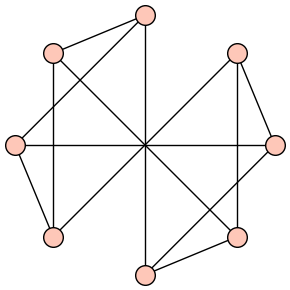

In [149]:
G.plot(vertex_labels=False, layout ='circular')

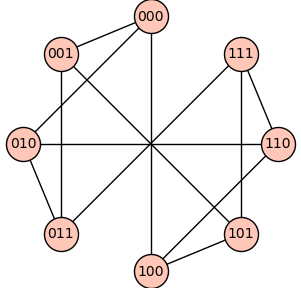

In [150]:
# Hint!
G.plot(layout ='circular', vertex_size=600)

This is the Cube Graph! The cube graph is planar.

#### For 1 point:

In [151]:
G = graphs.CubeGraph(4)

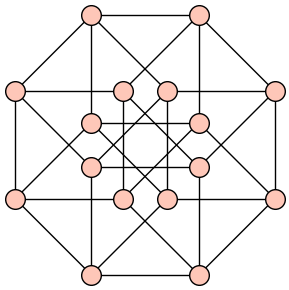

In [152]:
G.plot(vertex_labels=False)

The hypercube of dimension 4 is not planar...

### Counting the points... Do we have a winner?

# V. Databases

In [153]:
import matplotlib.pyplot as plt  # So pictures of posets fit on the slides
plt.rcParams['figure.figsize'] = [8, 4]

## Interface with databases

**Two principles of SageMath that we have encoutered before:**
- It works well with other open-source software
- SageMath serves as a knowledge base: it countains a lot of algorithms and description of objects

The same principle is true for **open databases**!
<img src="images/logooeis.jpg" width="250"><img src="images/logo_findstat.png" width="150"/>
- OEIS
- FindStat
- A few other databases for knots, elliptic curves, etc.

## Online Encyclopedia of Integer Sequences: https://oeis.org/

- An *integer sequence* is a function $\{1,2,3,\ldots\} \to \mathbb{Z}$ (so it has a first term, and may have a last term; all images are integers).
- Likely the **most important database for math**.
- Very useful for number theory and combinatorics.
- Contains 364,067 sequences (as of Wednesday)!
- Beyond the data, entries contain formulae, generating functions, properties and references



## OEIS examples
### Catalan numbers
https://oeis.org/A000108

A refinement of the Catalan numbers are the **Narayana numbers**.

In [154]:
oeis('narayana')

0: A001263: Triangle of Narayana numbers T(n,k) = C(n-1,k-1)*C(n,k-1)/k with 1 <= k <= n, read by rows. Also called the Catalan triangle.
1: A000930: Narayana's cows sequence: a(0) = a(1) = a(2) = 1; thereafter a(n) = a(n-1) + a(n-3).
2: A090181: Triangle of Narayana (A001263) with 0 <= k <= n, read by rows.

https://oeis.org/A001263


What is your favourite sequence?

Some more famous sequences:

- The prime numbers, A000040
- The Fibonacci numbers, A000045

And sequences with two parameters also appear in the OEIS, as an array or a triangle.
- Pascal's triangle, A007318
- Triangle of Stirling numbers of second kind, A008277

### Identifying a sequence...

What is this?

```python
oeis(list(str(float(pi))))`
```

In [155]:
# What is this?

oeis(list(str(float(pi))))

0: A000796: Decimal expansion of Pi (or digits of Pi).
1: A379323: Decimal expansion of log((2*5! + (8 - 1)!)^sqrt(9) + 4! + (3!)!)/sqrt(67).
2: A212131: Decimal expansion of k such that e^(k*sqrt(163)) = round(e^(Pi*sqrt(163))).

### $\pi$

> `oeis(list(str(float(pi))))`

Takes $\pi$, `float` expands its decimal (to 16 digits of precision), `str` changes the number into a *string* (so a sequence) of characters, lists splits them. Asking the OEIS gives some choices for sequences.

In [156]:
print(pi)
print(float(pi))
print(str(float(pi)))
print(list(str(float(pi))))

pi
3.141592653589793
3.141592653589793
['3', '.', '1', '4', '1', '5', '9', '2', '6', '5', '3', '5', '8', '9', '7', '9', '3']


## OEIS: 364,067 sequences?

- The OEIS is a **comprehensive** list of integer sequences.
- It contains pretty much any sequences you can think of, so it can be helpful for your research!
- Some sequences are not very relevant.
- If you know a relevant sequence, e.g. something that appears in a research paper, **add it!** The OEIS is written by volunteer mathematicians like you and I.

## FindStat

- A **statistic** is a function from a combinatorial object $\mathcal{O}$ to a set of number.
  Most often, it is a function $\mathcal{O} \to \mathbb{N}$, but the image can be in $\mathbb{Q}$ or $\mathbb{Z}$.
- Combinatorial objects are the types we know: Permutations, subsets, compositions, graphs, ...
- Just like the OEIS, FindStat is a collaborative online database.
- It contains two types of functions: **statistics** and **maps** (function from a combinatorial object to another).
- Can be used with a detailed search engine on the interface.
- As of last week, the database contains 1908 statistics and 305 maps on 24 collections by 96 contributors.
- On top of that, the search engine can compose the functions to give more relevant results.

In [157]:
# Example
# For the execution of FindStat code
from sage.databases.findstat import *
findstat()._allow_execution = True

list_for_search = []
for n in range(2,5):
    for path in DyckWords(n):
        list_for_search.append((path, findstat(445)(findmap(118)(path))))
dict_for_search = dict(list_for_search)
findstat(dict_for_search)

0: St000445oMp00118 (quality [100, 100])
1: St000445oMp00121oMp00118 (quality [100, 100])
2: St001126oMp00030oMp00118 (quality [100, 100])
3: St001232oMp00222oMp00199 (quality [14, 60])
4: St001879oMp00047oMp00026 (quality [14, 60])
5: St001880oMp00047oMp00026 with offset 1 (quality [14, 60])
6: St001880oMp00242oMp00143 with offset 2 (quality [14, 40])

I made up some statistic for some Dyck Paths, and store them as tuples in `list_for_search`. Can you find what is that statistics?

In [158]:
for pair in list_for_search:
    print(ascii_art(pair[0]), pair[1])

/\/\ 0
 /\ 
/  \ 2
/\/\/\ 0
   /\ 
/\/  \ 1
 /\   
/  \/\ 1
 /\/\ 
/    \ 1
  /\  
 /  \ 
/    \ 3
/\/\/\/\ 0
     /\ 
/\/\/  \ 1
   /\   
/\/  \/\ 1
   /\/\ 
/\/    \ 2
    /\  
   /  \ 
/\/    \ 2
 /\     
/  \/\/\ 0
 /\  /\ 
/  \/  \ 0
 /\/\   
/    \/\ 2
 /\/\/\ 
/      \ 2
    /\  
 /\/  \ 
/      \ 2
  /\    
 /  \   
/    \/\ 1
  /\    
 /  \/\ 
/      \ 1
  /\/\  
 /    \ 
/      \ 2
   /\   
  /  \  
 /    \ 
/      \ 4


## FindStat Interface

- Go to www.findstat.org
- Choose the **collection**: this is the type of combinatorial object, e.g. Dyck Paths
- Enter the data manually in the form provided.

Or
- Call FindStat from SageMath!


In [159]:
findstat(list_for_search)

0: St000445oMp00118 (quality [100, 100])
1: St000445oMp00121oMp00118 (quality [100, 100])
2: St001126oMp00030oMp00118 (quality [100, 100])
3: St001232oMp00222oMp00199 (quality [14, 60])
4: St001879oMp00047oMp00026 (quality [14, 60])
5: St001880oMp00047oMp00026 with offset 1 (quality [14, 60])
6: St001880oMp00242oMp00143 with offset 2 (quality [14, 40])

This gives several options, of varying quality... The top three are high quality, meaning that they match 100%. We can ask FindStat what they are.

Exploring
> 0: St000445oMp00118 (quality [100, 100])

We start with the statistic, then the map. We are interested in Statistic 445.

In [160]:
findstat(445).description()

'The number of rises of length 1 of a Dyck path.'

One can also get the code used to generate the statistic.

In [161]:
findstat(445).code()

'def statistic(D):\r\n    return list(D.rise_composition()).count(1)\r\n'

If we are interested in the distribution, we can ask for the generating function or ask to browse the OEIS for the corresponding sequence.

In [162]:
findstat(445).generating_functions()

{1: q,
 2: q^2 + 1,
 3: q^3 + 3*q + 1,
 4: q^4 + 6*q^2 + 4*q + 3,
 5: q^5 + 10*q^3 + 10*q^2 + 15*q + 6,
 6: q^6 + 15*q^4 + 20*q^3 + 45*q^2 + 36*q + 15,
 7: q^7 + 21*q^5 + 35*q^4 + 105*q^3 + 126*q^2 + 105*q + 36}

In [163]:
findstat(445).oeis_search()

Searching the OEIS for "1  1,0,1  1,3,0,1  3,4,6,0,1  6,15,10,10,0,1  15,36,45,20,15,0,1  36,105,126,105,35,21"


0: A091867: Triangle read by rows: T(n,k) = number of Dyck paths of semilength n having k peaks at odd height.

We can also ask for reference, or get all of this at one by typing `browse()`.

In [164]:
findstat(445).references()

0: [1]  Kangro, K., Pourmoradnasseri, M., Theis, D. O., Short note on the number of 1-ascents in dispersed dyck paths [[arXiv:1603.01422]]

In [165]:
findstat(445).browse()  # opens a tab in a browser

## Discovering new math with FindStat

- Just like with the OEIS, FindStat serves as a repository for knowledge
- I use it to know how to compute some maps, to know their properties or to get a list of common maps or statistics
- Here is an example of a map I recently discovered:

### Map00257: Alexandersson--Kebede
<img  style="float: center;" src="images/findstat-screenshot.png" width="600"/>

## Pitfalls with using databases
- The databases are not stored on your computer, so you *need* an internet connection to access them
- If you are using SageMath on some servers (such as CoCalc), it does not let you access the internet unless you pay.
- As with everything open (and everything not open as well), there may be errors in the content. However, both the OEIS and FindStat make much fewer mistakes than any mathematician working by hand!

## An application in my own research

Recently, Jennifer Elder, Erin McNicholas, Jessica Striker, Amanda Welch and myself defined *interval-closed subsets* of a partially ordered set (poset, for short). (https://arxiv.org/abs/2307.08520)
These subsets are such that if $x \leq y \leq z$ in a poset and both $x$ and $z$ belong to the interval-closed subset, then $y$ does as well:

$$x\leq y \leq z \text{ and } x,z \in I \implies y \in I.$$

We were trying to count some types of interval-closed sets.


We draw posets with cover relations, with the smaller items at the bottom, and the larger at the top.

Example: divisors poset. We say that $x \preceq y$ if $x$ divides $y$, as an integer.

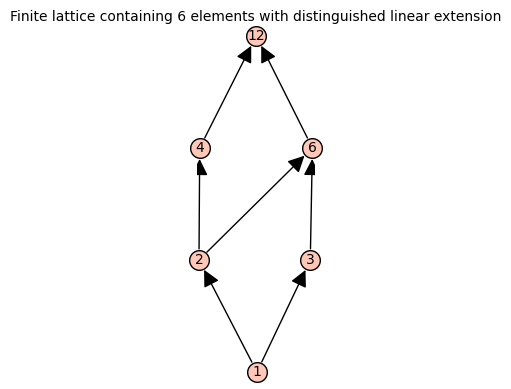

In [166]:
P = Posets.DivisorLattice(12); P

In [167]:
def interval_closed_sets(P):
    ICS = []
    for A in P.antichains_iterator():
        I = P.subposet(P.order_ideal(A))
        Q = P.subposet(Set(I).difference(A))
        for B in Q.antichains_iterator():
            ICS.append(Set(I).difference(Set(P.order_ideal(B))))
    return ICS

def interval_closed_sets_count(P):
    ICS_count = 0
    for A in P.antichains_iterator():
        I = P.subposet(P.order_ideal(A))
        Q = P.subposet(Set(I).difference(A))
        ICS_count += len(list(Q.antichains()))
    return ICS_count

In [168]:
#For graphing
def subset_color_dictionary(P, subset):
    output = {}
    output['red']= subset
    return output

def subset_plot(P, subset):
    plot = P.plot(element_colors = subset_color_dictionary(P, subset))
    return plot

It is known that divisors posets can be drawn as _rectangle posets_. We wanted to count, for divisors posets of numbers with two different prime factors, a specific type of interval-closed sets, namely those that have elements in all the chains.

In [169]:
def subset_color_dictionary_chains(a, b):
    output = {}
    for x in range(a): 
        color = list(colors)[x+11]  # The offset  (11) is just so the colors are nicer
        output[color] = [(x, y) for y in range(b)]
    return output

def color_all_a_chains(a, b, label=True):
    P = Posets.ProductOfChains((a, b))
    coloring = subset_color_dictionary_chains(a, b)
    return P.plot(element_colors = coloring, label_elements=label)

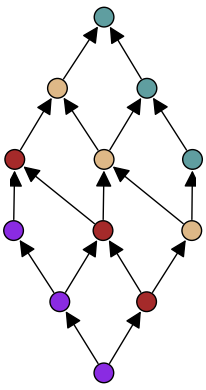

In [170]:
# All four chains have a different color here
color_all_a_chains(4,3, label=False)

We were wondering how many interval-closed sets had items in all $a$ chains for the divisors poset of $2^{a-1}3^{b-1}$.

The left-hand side subset (in red) has items in all 4 chains, while the one on the right does not (no element in top chain).

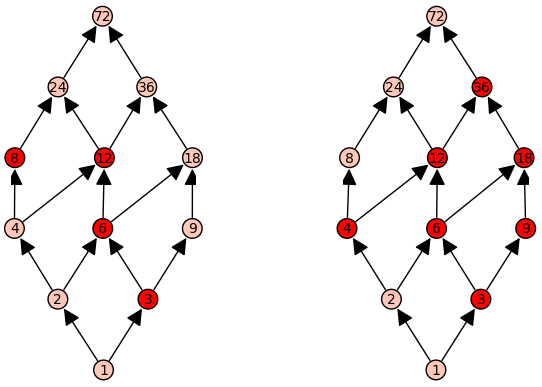

In [171]:
P = Posets.DivisorLattice(72);
graphics_array([subset_plot(P, (3,6,8,12)), subset_plot(P, (3,4,6,9,12, 18, 36))])

### Counting interval-closed sets with items in all $a$ chains
(Naive) method:
- listing all interval-closed sets
- For each of them, checking if they have items in all $a$ chains
- Counting the successful candidates

**Questions**:
- How is this on memory?
- How is this on time?

In [172]:
def has_elements_in_all_a_chains(I, a):
    chain = [False for _ in range(a)]
    try:
        for x in I:
            chain[x[0]] = True
    except:
        print(x, chain, a)
    if chain == [True for _ in range(a)]:
        return True
    return False

def count_ICS_that_have_elements_in_all_a_chains(a, b):
    count = 0
    P = Posets.ProductOfChains([a, b])
    for A in P.antichains_iterator():
        J = P.subposet(P.order_ideal(A))
        Q = P.subposet(Set(J).difference(A))
        for B in Q.antichains_iterator():
            I = Set(J).difference(Set(P.order_ideal(B)))
            if has_elements_in_all_a_chains(I, a):
                count += 1
    return count

In [173]:
counts = []
for s in range(2,9):
    counts.extend([count_ICS_that_have_elements_in_all_a_chains(s-b, b) for b in range(1, s+1)])
print(counts, '\n', oeis(counts))  # Requires internet access. If you don't have it, replace this line with `print(counts)`, and enter the output in the OEIS.

[1, 1, 1, 3, 1, 1, 6, 6, 1, 1, 10, 20, 10, 1, 1, 15, 50, 50, 15, 1, 1, 21, 105, 175, 105, 21, 1, 1, 28, 196, 490, 490, 196, 28, 1] 
 0: A001263: Triangle of Narayana numbers T(n,k) = C(n-1,k-1)*C(n,k-1)/k with 1 <= k <= n, read by rows. Also called the Catalan triangle.


The first comment in the entry for sequence A001263 of the OEIS is that it is the "number of antichains (or order ideals) in the poset 2\*(k-1)\*(n-k)".

This put us on track to establish a bijection between order ideals of 2*a*(b-1) (the divisor poset of $2^{a-1}3^{b-2}5$) and interval-closed sets of a*b (the divisor poset of $2^{a-1}3^{b-1}$) with items in all $a$ chains.

In our paper (Section 4.1), we indeed show that this is a bijection, and conclude that they are counted by the Narayana numbers, as suggested by the OEIS.

**<span style="color:red">Open problem</span>**

* It is an open problem to find the number of interval-closed sets of a divisor poset in general, and even of the divisor poset of $2^{a}3^{b}$. Some partial results appear in our paper. Among them, we know the number of interval-closed sets of the divisor poset of $2 \cdot3^{b}$.

See the [paper]((https://arxiv.org/abs/2307.08520) for details if you are interested in working on this problem, or the [Sage notebook with computations for this project](https://cocalc.com/share/public_paths/5822cfb981981aef12b7b93c71695d92bfb616c7).

### Takeaway

- Databases are incredibily helpful in finding bijections, or noticing correspondence in integer sequences
- There is definitely something exciting in realizing that the data you have also appears somewhere else (just like when you hear sampling from a song in another one, and are trying to recognize it). It usually suggests an **interesting bijection**.

# A Bijectionist's toolkit

There is now a tool to find bijections automatically!

- Very recent tool
- Included in SageMath starting with version 10.0.
- Find bijections automatically, after you give it a start set, an end set, and constraints.

This worksheet is to be used with the Bijectionist's toolkit, a tool that comes with SageMath 10.0 onwards.
Extended documentation can be found at https://doc.sagemath.org/html/en/reference/combinat/sage/combinat/bijectionist.html, and an extended abstract written for the Conference _Formal Power Series and Algebraic Combinatorics_ is available [here](https://www.mat.univie.ac.at/~slc/wpapers/FPSAC2023/91.pdf) and contains multiple examples.

Author: Nadia Lafrenière, [nadia.lafreniere@concordia.ca](mailto:nadia.lafreniere@concordia.ca)

Acknowledgements: The author is grateful to the developers of the tool (Alexander Grosz, Tobias Kietreiber, Stephan Pfannerer and Martin Rubey), as well as Stephan Pfannerer for his patient explanations and encouraging thoughts.

## Setup

- Start set $A$
- End set $B$
- We want a bijection $A \to B$. Of course, we need that $|A| = |B|$.

### Constraints
The bijections will be found by a computer, so they might not be beautiful, or interesting... This is why we give it *constraints*.

Example of constraints:
- It must preserve a statistics
- We might want it to commute with some other functions
- We might want to fix some values of the bijection

### Interesting bijections

We care about bijections because:
- They show that two sets have the same size, and this is sometimes hard otherwise
- They show that two features, or statistics, have the same distribution. 
- **Example** : The Narayana numbers count both the number of Dyck Paths with $2n$ steps and $k$ peaks, and the number of rooted trees with $n$ nodes and $k$ leaves. So there must exist a bijection that sends peaks of the Dyck path to leaves of the tree. (See [Wikipedia](https://en.wikipedia.org/wiki/Narayana_number#Rooted_trees).)

In [174]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [4, 2]

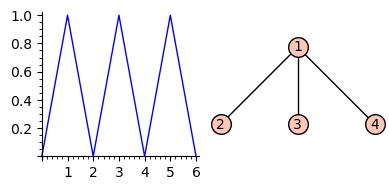

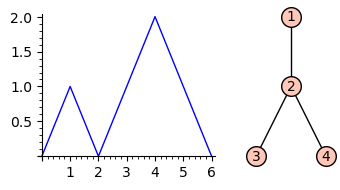

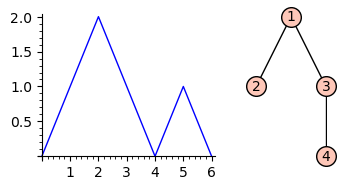

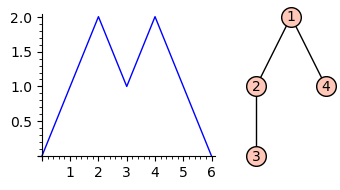

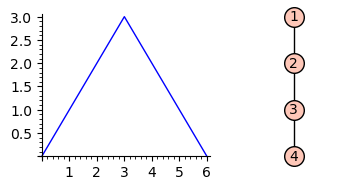

In [175]:
n = 3
A = DyckWords(n)
B = OrderedTrees(n+1)

def alpha1(d): return len(d.peaks())

def beta1(t): return findstat(167)(t)  # findstat statistics #167 is the number of leaves in an ordered tree

bij = Bijectionist(A, B)  # We call the Bijectionist!

bij.set_statistics((alpha1, beta1))

sol = next((bij.solutions_iterator()))

for key in sol.keys():
    show(graphics_array([key.plot(), sol[key].plot()]))

We can even see what all the constraints are on the bijection.

In [176]:
list(bij.minimal_subdistributions_iterator())

[([[1, 0, 1, 0, 1, 0]], [[[], [], []]]),
 ([[1, 1, 1, 0, 0, 0]], [[[[[]]]]]),
 ([[1, 0, 1, 1, 0, 0], [1, 1, 0, 0, 1, 0], [1, 1, 0, 1, 0, 0]],
  [[[], [[]]], [[[]], []], [[[], []]]])]

**Exercise**: how many solutions are there, to do a bijection that meets our constraints (for $n=4$)?

There are $6!\times 6!$ possible bijections, because in each block, we can match any path with any tree.

### Pros and cons of the bijectionist
The bijectionist requires that the statistics satisfies $$\sum_{\pi} q^{s(\pi)} = \sum_{\pi} q^{\tau(\pi)},$$
so that they are equidistributed.

- It is not hard to check whether two statistics are equidistributed, or whether two sets are even in bijection with one another.
- The power of the bijectionist toolkit is that it allows to add constraints that makes *ad hoc* checking hard.

The bijectionist can give a bijection that works for example for all values less than 10. However, it does so by matching elements to satisfy constraints, but it might not give a general description to make it a nice conjecture.

## Bijectionist's Takeaway
- The bijectionist is a new tool, that is very powerful to put us on track of some bijections
- It would be even stronger if it could come with a story to explain how the bijection works, but this is the job of combinatorialists
- It works well with open databases such as FindStat.